In [2]:

from matplotlib import cm 
import os 
from PIL import Image
import numpy as np  
import skimage.io as skio 
import skimage.segmentation as sksegmentation
import skimage.morphology as skmorph
import skimage.measure as skmeasure
import scipy.ndimage as ndimage
import sys
from imageio.v2 import imread,imwrite
import pickle
import unwrap3D.Image_Functions.image as image_fn
import unwrap3D.Unzipping.unzip as uzip
import cv2
import matplotlib.pyplot as plt

sys.path.append('../unwrap2D')
import unwrap2D
sys.path.append('../utils')
import run_stack
import importlib
import split_window2D
import window_overlay_display
importlib.reload(run_stack)
importlib.reload(split_window2D)
importlib.reload(window_overlay_display)

import window_overlay_display
importlib.reload(window_overlay_display)
from run_stack import unwrap2D_all_TF, window_all_TF, calculate_window_intensity, calculate_all_windowd, \
                        plot_window_d
from area_correction import correct_unwrap_img
from window_overlay_display import window_display, plot_windows_tab20

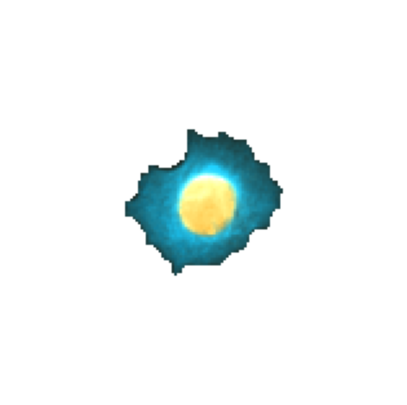

In [3]:
# load original image
cell_name = "002_52"
reproducibility_save_path = f"/archive/bioinformatics/Danuser_lab/shared/Yu_Felix_Roshan/1_Paper_All_Reproducibility_Files/Figure_1/Cell_Representative/{cell_name}"
os.makedirs(reproducibility_save_path,exist_ok=True)
ff1 = cell_name.split("_")[0]
ff2 = cell_name.split("_")[1]
img = Image.open(f"/archive/bioinformatics/Danuser_lab/shared/Yu_Felix_Roshan/Datasets/Cellpose/single_cell_imgs/train/markers/{ff1}/{ff2}.png")
img = np.array(img)
img_size_vis = img.shape[:2]
rgb = image_fn.normalize(img, pmin=1, pmax=99.8, clip=True)
#rgb = np.asarray(img).astype(float) / np.max(img)
# rgb = img
r = rgb[..., 0]
g = rgb[..., 1]
b = rgb[..., 2]

ORANGE = np.array([1.0, 0.55, 0.0])
BLUE   = np.array([0.0, 0.75, 1]) 
PURPLE = np.array([0.6, 0.3, 0.8])    

img_orange = r[..., None] * ORANGE
img_blue   = g[..., None] * BLUE
img_purple = b[..., None] * PURPLE

img_disp = img_orange + img_blue + img_purple
# img_disp = np.clip(img_disp, 0, 1)

bg_mask = np.mean(rgb, axis=2) < 1e-6
img_disp[bg_mask] = 1.0

# gamma = 0.7
# img_disp = img_disp ** gamma
img_disp = np.clip(img_disp, 0, 1)

plt.figure(figsize=(5,5))
plt.imshow(img_disp, aspect='auto')
plt.axis('off')
plt.xlim(50,200)
plt.ylim(200,50)
plt.savefig(
    os.path.join(reproducibility_save_path, f"{cell_name}_ori_img.svg"),
    format="svg",
    bbox_inches="tight",
    pad_inches=0
)

plt.show()



# Load and plot uRegister results first

7 56


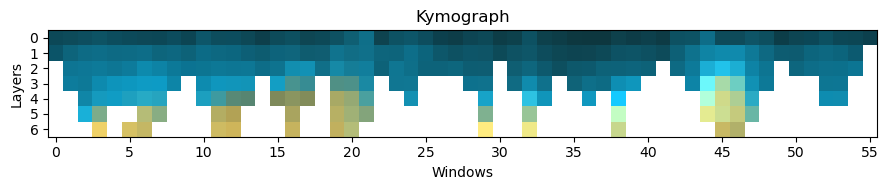

In [4]:
import scipy.io as sio
base_path = f"/archive/bioinformatics/Danuser_lab/shared/Yu_Felix_Roshan/paper/Fig1-cells/cell_candidates_final/{cell_name}/uRegisterPackage/window_sampling/"
save_path = f"/archive/bioinformatics/Danuser_lab/shared/Yu_Felix_Roshan/1_Paper_All_Reproducibility_Files/Figure_1/Cell_Representative/{cell_name}"
mat1 = sio.loadmat(os.path.join(base_path, "Raw images - channel 1.mat"))
mat2 = sio.loadmat(os.path.join(base_path, "Raw images - channel 2.mat"))
mat3 = sio.loadmat(os.path.join(base_path, "Raw images - channel 3.mat"))


img1 = mat1['samples']['avg'][0][0]
img2 = mat2['samples']['avg'][0][0]
img3 = mat3['samples']['avg'][0][0]

img1 /= np.nanmax([img1,img2,img3])
img2 /= np.nanmax([img1,img2,img3])
img3 /= np.nanmax([img1,img2,img3])

img1 = img1[...,None] * ORANGE
img2 = img2[...,None] * BLUE
img3 = img3[...,None] * PURPLE

# img1 = mat1['samples']['avg'][0][0]
# img2 = mat2['samples']['avg'][0][0]
# img3 = mat3['samples']['avg'][0][0]
img = img1 + img2 + img3
# gamma = 0.7  
# img = img ** gamma
img = np.clip(img, 0, 1)
# rgb = np.stack([img1, img2, img3], axis=0)
# rgb_layers = np.stack(rgb_layers, axis=0)
# rgb = img1 + img2 + img3
#img_disp = np.clip(rgb, 0, 1)
# gamma = 0.7  
# img_disp = img_disp ** gamma
# img_disp = np.clip(img_disp, 0, 1)
# img_disp = rgb / np.nanmax(rgb)
img_disp = np.transpose(img, (1,0,2))
plt.figure(figsize=(9, 2))
im = plt.imshow(img_disp, aspect='auto')


R_NUM = img1.shape[1]
THETA_NUM = img1.shape[0]
print(R_NUM, THETA_NUM)
plt.ylabel("Layers")
plt.xlabel("Windows")
plt.yticks([i for i in range(R_NUM)])
#plt.yticks([i for i in range(R_NUM-1,-1,-1)], [i + 1 for i in range(R_NUM)])
num_windows = img_disp.shape[1]
xticks = np.arange(0, num_windows, 5)
plt.xticks(xticks)

plt.title("Kymograph")
# plt.colorbar()
# plt.colorbar(im, fraction=0.03, pad=0.02)
plt.savefig(os.path.join(save_path, "kymograph_uRegister.svg"), dpi=600)
plt.tight_layout()
plt.show()




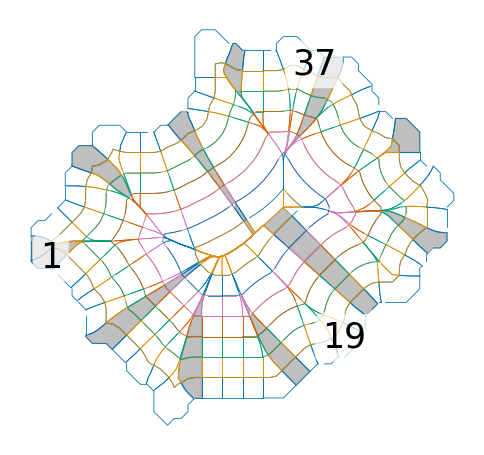

In [5]:
base_path = f"/archive/bioinformatics/Danuser_lab/shared/Yu_Felix_Roshan/paper/Fig1-cells/cell_candidates_final/{cell_name}/uRegisterPackage/windows/"
ff = "windows_frame__frame_1.mat"

svg, windows_layers = plot_windows_tab20(os.path.join(base_path, ff), THETA_NUM=THETA_NUM, R_NUM=R_NUM, img=None,save_name=f'{cell_name}_uRegister',
                                output_folder=save_path, frame_n= 1)

# Load and plot uUnwrap Results based on the uRegister results

In [6]:
# load pre-run unwrap_results
file_path = "/work/bioinformatics/s440708/unwrap2D_paper/temporary_save_files/figure1_cellpose_unwrap2D/"

files = cell_name


save_v_out = os.path.join(file_path, files,'v_out_stack.pkl')
save_f_steps_out = os.path.join(file_path, files,'f_steps_out_stack.pkl')
save_v_img_out = os.path.join(file_path,files,'v_img_stack.pkl')
save_bdy_index = os.path.join(file_path, files,'bdy_index_stack.pkl')



with open(save_v_out, 'rb') as file:
    v_out_stack = pickle.load(file)

with open(save_f_steps_out, 'rb') as file:
    f_steps_out_stack = pickle.load(file)

with open(save_v_img_out, 'rb') as file:
    v_img_out_stack = pickle.load(file) 

with open(save_bdy_index, 'rb') as file:
    bdy_index_stack = pickle.load(file)

# plot to check if the vertices look all good
# fig, ax = plt.subplots(figsize=(5,5))
# plt.triplot(v_out_stack[0][:,1],v_out_stack[0][:,2],f_steps_out_stack[0],'g-',linewidth=0.1)
# plt.savefig(os.path.join(file_path, files,'vertices.png'))

In [7]:
prefix1 = files.split("_")[0]
prefix2 = files.split("_")[1]
img = imread(f"/archive/bioinformatics/Danuser_lab/shared/Yu_Felix_Roshan/Datasets/Cellpose/single_cell_imgs/train/processed/markers_256/{prefix1}/{prefix2}.png")
uv_grid_size = 1024 
uv_2D = v_out_stack[0]
uv_vertices = v_img_out_stack[0]
uv_faces = f_steps_out_stack[0]
unwrap_params, unwrap_img_r, unwrap_valid_mask = unwrap2D.resample_disk_grid_to_img_grid(uv_2D[:,1:], 
                                                                                        uv_vertices[:,1:], 
                                                                                        uv_faces, 
                                                                                        img_I=img[...,0], 
                                                                                        raster_size=uv_grid_size, 
                                                                                        border_pad=32)


unwrap_img_g = image_fn.map_intensity_interp2(unwrap_params.reshape(-1,2),
                                                img.shape[:2], 
                                                img[...,1],method='linear', fill_value=np.nan).reshape(unwrap_params.shape[:2])
unwrap_img_g[unwrap_valid_mask==0] = 0

In [8]:

unwrap_img_b = image_fn.map_intensity_interp2(unwrap_params.reshape(-1,2),
                                                img.shape[:2], 
                                                img[...,2]).reshape(unwrap_params.shape[:2])
unwrap_img_b[unwrap_valid_mask==0] = 0

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

unwrap_img_gray = image_fn.map_intensity_interp2(unwrap_params.reshape(-1,2),
                                                img.shape[:2], 
                                                img_gray).reshape(unwrap_params.shape[:2])

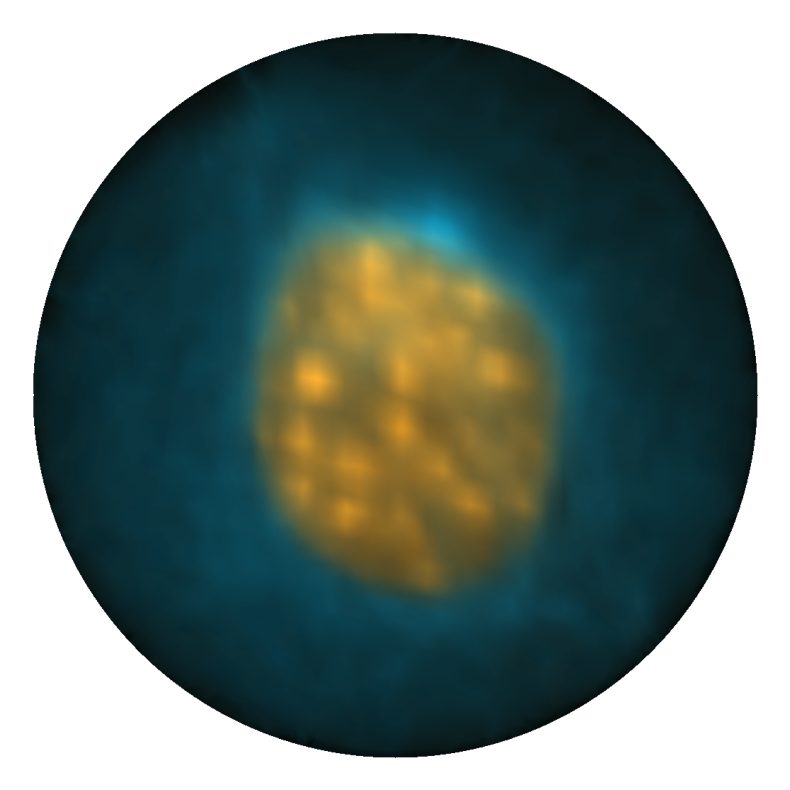

In [9]:
max_val = np.nanmax((unwrap_img_r, unwrap_img_g, unwrap_img_b))
r = unwrap_img_r / max_val
g = unwrap_img_g / max_val
b = unwrap_img_b / max_val


unwrap_img_cb = np.zeros((*r.shape, 3))


img_orange = r[..., None] * ORANGE
img_blue   = g[..., None] * BLUE
img_purple = b[..., None] * PURPLE 
unwrap_img_cb = img_orange + img_blue + img_purple
unwrap_img_cb = np.clip(unwrap_img_cb, 0, 1)
bg_mask = (unwrap_img_cb[..., 0] == 0) & \
          (unwrap_img_cb[..., 1] == 0) & \
          (unwrap_img_cb[..., 2] == 0)
unwrap_img_cb[bg_mask] = 1.0
# gamma = 0.7  
# unwrap_img_cb = unwrap_img_cb ** gamma
unwrap_img_cb = np.clip(unwrap_img_cb, 0, 1)

plt.figure(figsize=(10,10))
plt.imshow(unwrap_img_cb)
plt.axis('off')
plt.savefig(os.path.join(reproducibility_save_path, f"{cell_name}_unwrap_img.svg"))
plt.show()


In [10]:
unwrap_save = False
# THETA_NUM = 60
# R_NUM = 12
reference_n = 20


unwrap_imgs_stack = [unwrap_img_r, 
                            unwrap_img_g,
                            unwrap_img_b]
unwrap_params_stack = [unwrap_params for _ in range(3)]
unwrap_valid_mask_stack = [unwrap_valid_mask for _ in range(3)]
window_stack = window_all_TF(unwrap_imgs_stack, unwrap_params_stack, raster_size = uv_grid_size)

all_intensity, all_edge_xy, all_edge_uv = calculate_window_intensity(window_stack, 
                                                        r_num = R_NUM,
                                                          theta_num = THETA_NUM,
                                                           layer_n = 1)

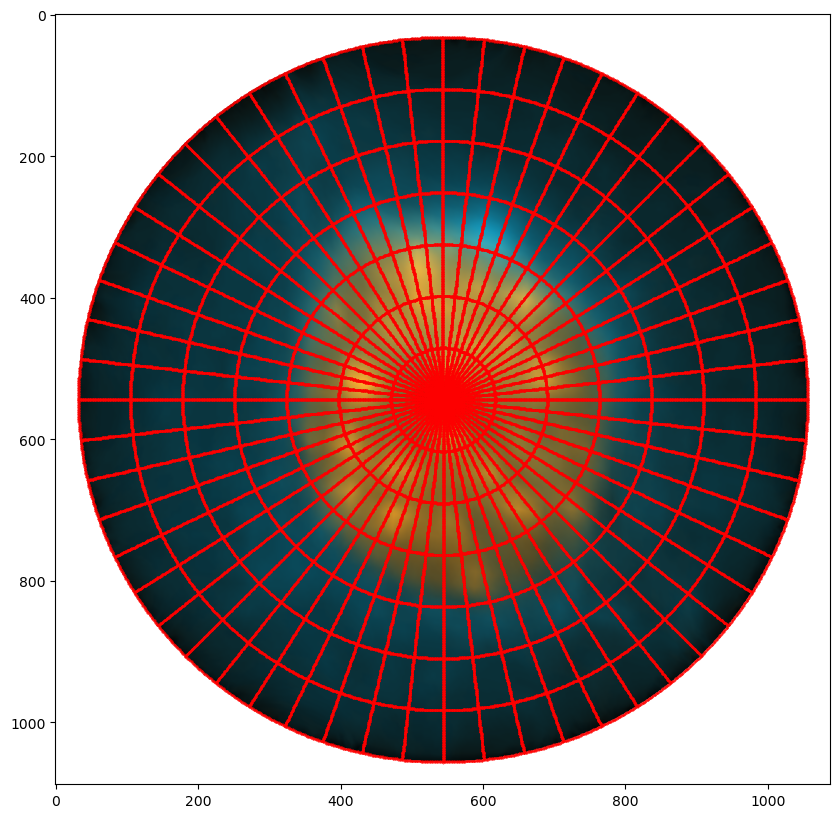

In [11]:
# unwrap_img = np.dstack([unwrap_img_r, 
#                             unwrap_img_g,
#                             unwrap_img_b])
# unwrap_img_= unwrap_img/np.max(unwrap_img)
window_stack[0].plot_disk_window(img = unwrap_img_cb)

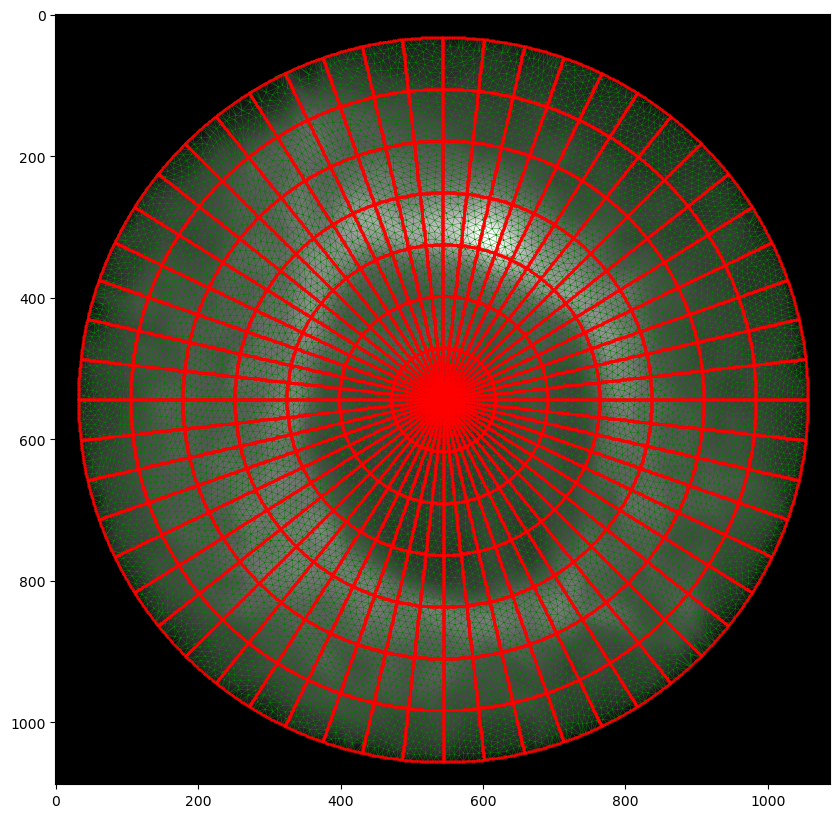

In [12]:
window_stack[1].plot_window(v_out_stack[0],f_steps_out_stack[0])

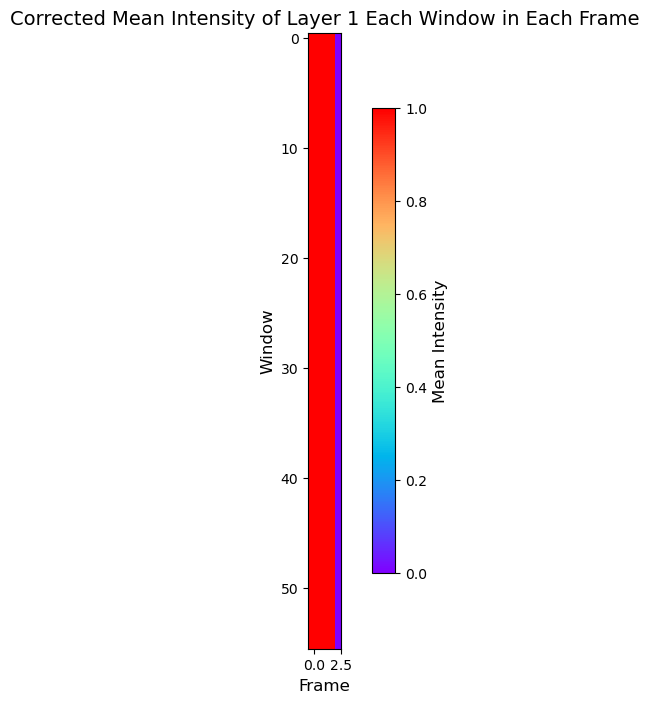

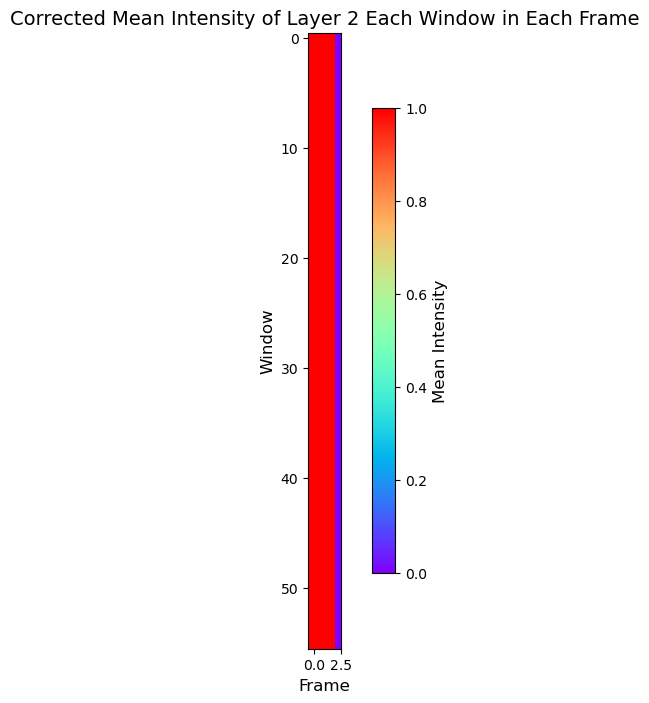

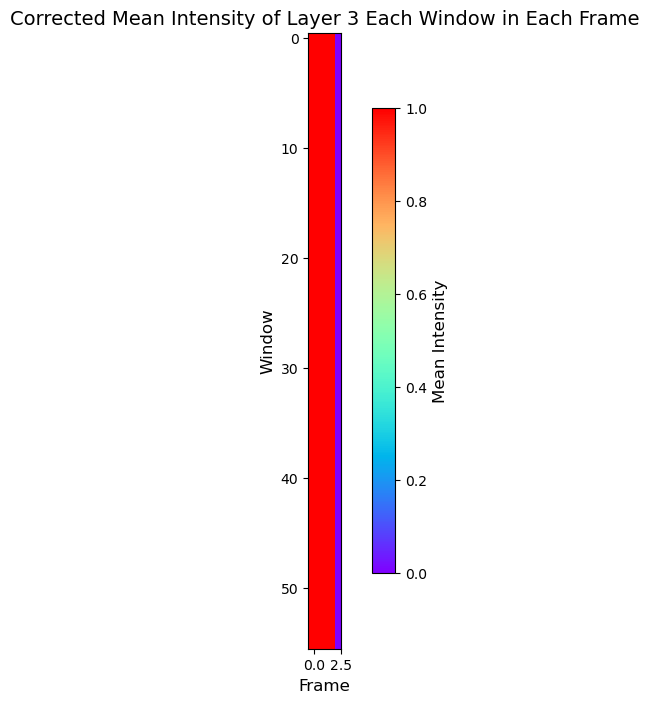

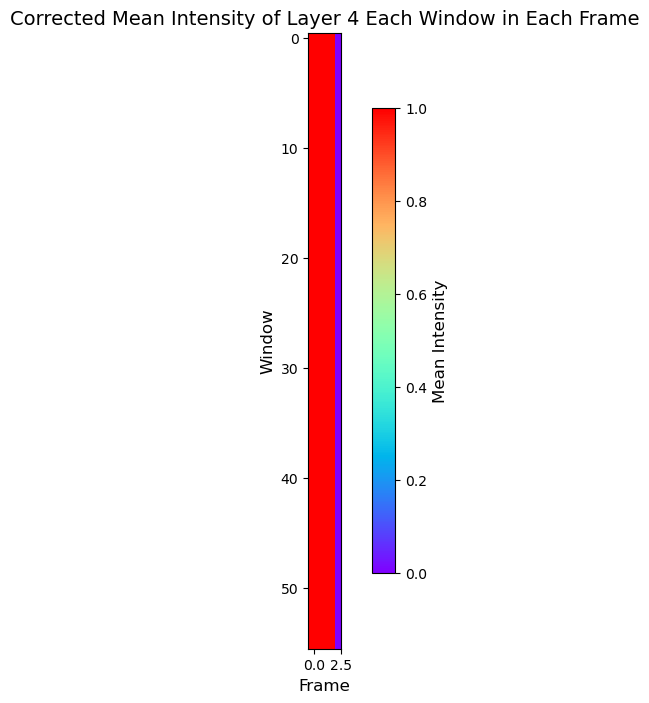

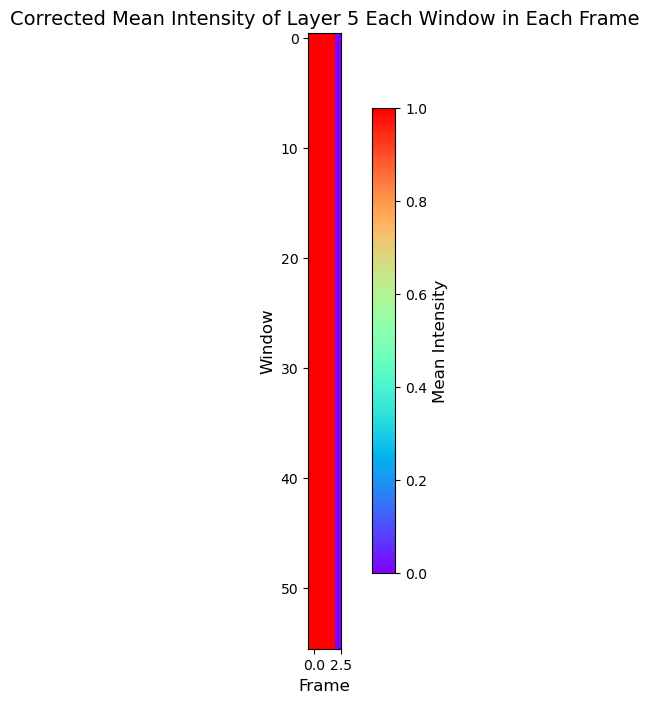

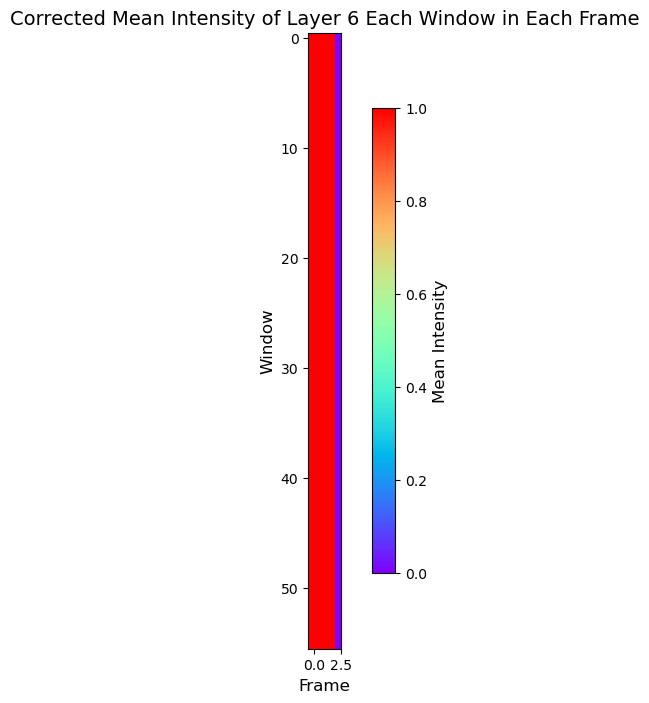

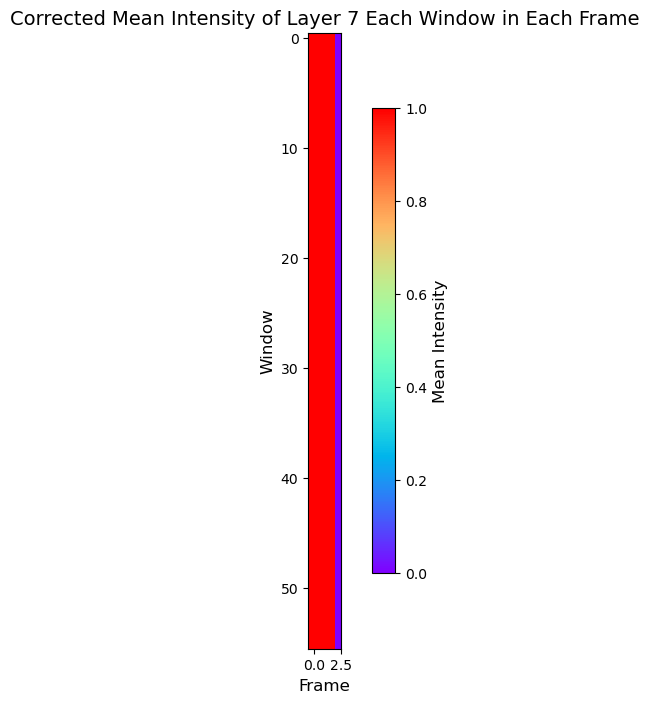

In [13]:

from plot_intensity_origin import *
# d = plot_window_d(window_acd_stack).T
all_masks = [window.segment_masks for window in window_stack]
len(all_masks)
rgb_layers = []
for i in range(1, R_NUM + 1):
    intensity = plot_intensity_origin(all_masks, unwrap_params_stack, unwrap_imgs_stack, unwrap_valid_mask_stack, radius=uv_grid_size/2-1, save_path = None, layer = i, theta_num = THETA_NUM)
    rgb_layers.append(intensity)
rgb_layers = np.stack(rgb_layers, axis=0)

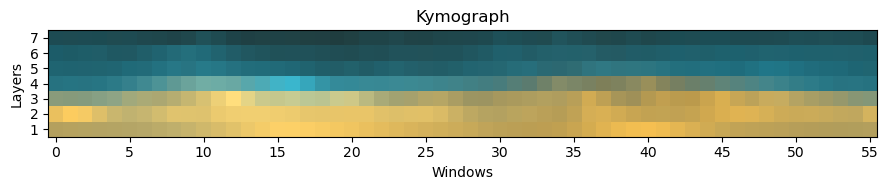

In [14]:
rgb_layers_ = rgb_layers / np.max(rgb_layers)  # or np.clip(rgb_image / 255, 0, 1)

r = rgb_layers_[..., 0]
g = rgb_layers_[..., 1]
b = rgb_layers_[..., 2]

# ORANGE = np.array([1.0, 0.55, 0.0])
# BLUE   = np.array([0.0, 0.75, 1]) 
# PURPLE = np.array([0.6, 0.3, 0.8])   


img_orange = r[..., None] * ORANGE
img_cyan   = g[..., None] * BLUE
img_purple = b[..., None] * PURPLE


img_disp = img_orange + img_cyan + img_purple
gamma = 0.7
img_disp = img_disp ** gamma
img_disp = np.clip(img_disp, 0, 1)
plt.figure(figsize=(9, 2))



plt.ylabel("Layers")
plt.xlabel("Windows")
plt.yticks([i for i in range(R_NUM-1,-1,-1)], [i + 1 for i in range(R_NUM)])
num_windows = img_disp.shape[1]
xticks = np.arange(0, num_windows, 5)
plt.xticks(xticks)
plt.imshow(img_disp, aspect='auto')
plt.ylabel("Layers")
plt.xlabel("Windows")
plt.title("Kymograph")
plt.savefig(os.path.join(reproducibility_save_path,f"Kymograph_{cell_name}.svg"))

plt.tight_layout()
plt.show()



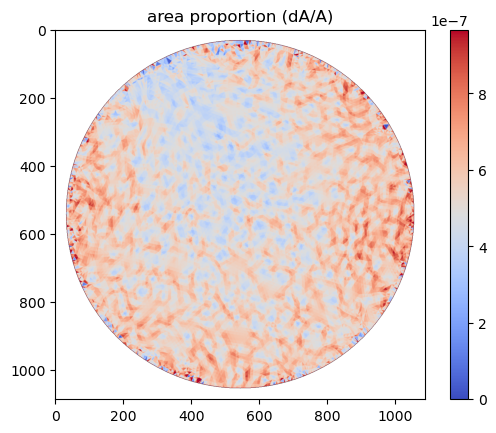

In [15]:
from unwrap3D.Unzipping.unzip import surface_area_uv
from copy import deepcopy

unwrap_params = unwrap_params_stack[0]
 
u,v = unwrap_params.shape[:2]
zeros = np.zeros((u, v, 1), dtype=unwrap_params.dtype)

unwrap_params_3d = np.concatenate((zeros, unwrap_params), axis=2)
dS_dudv, total_dS_dudv = surface_area_uv(unwrap_params_3d, eps=1e-12, pad=False)
# dS_dudv[np.isinf(dS_dudv)] = 0
dS_dudv[np.logical_not(unwrap_valid_mask)]=np.nan

#dS_dudv[np.logical_not(skmorph.binary_erosion(unwrap_valid_mask, skmorph.disk(1)))] = 0
total_dS_dudv = np.nansum(dS_dudv)

w = dS_dudv/total_dS_dudv

low = np.percentile(w[~np.isnan(w)], 0)
high = np.percentile(w[~np.isnan(w)], 99.5)
w_ = deepcopy(w)
w_[~np.isnan(w_)] = np.clip(w[~np.isnan(w)], low, high)
plt.imshow(w_, cmap='coolwarm')
plt.title("area proportion (dA/A)")
plt.savefig(os.path.join(reproducibility_save_path, "uv_area_proportion.svg"), dpi=600)
plt.colorbar()

In [16]:
import window_overlay_display
importlib.reload(window_overlay_display)
from window_overlay_display import window_display, draw_label_contours, plot_window_area_portion, calculate_uv_area_portion
w_ = calculate_uv_area_portion(unwrap_params_stack[0], unwrap_valid_mask_stack[0])
uv_area, xy_img, xy_portion, ratio_disk, ratio_value = plot_window_area_portion(
            all_masks, [unwrap_params_stack[0]], [w_], [unwrap_valid_mask_stack[0]],img_size = (300,300),
            radius = uv_grid_size/2 - 1, save_path = reproducibility_save_path, theta_num = THETA_NUM
        )

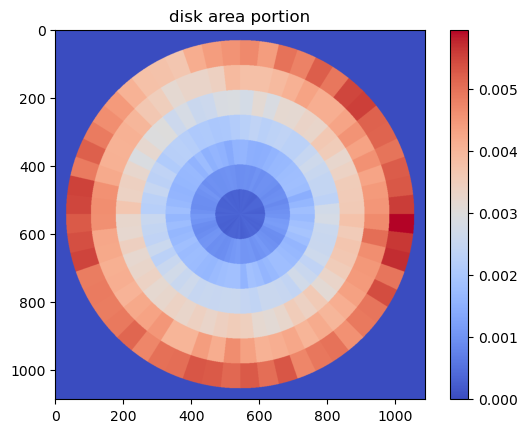

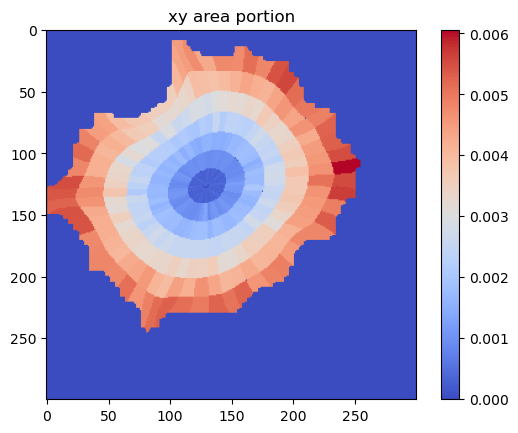

0.0 1.3201671429965454


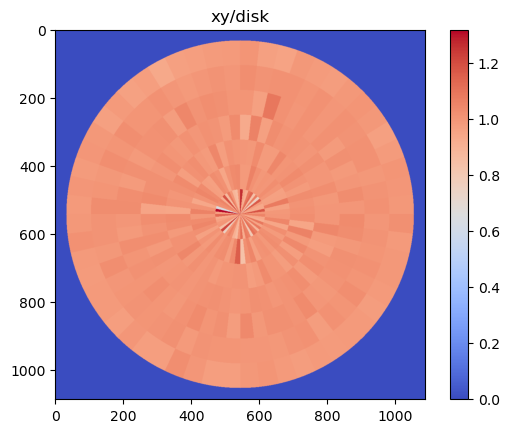

nan


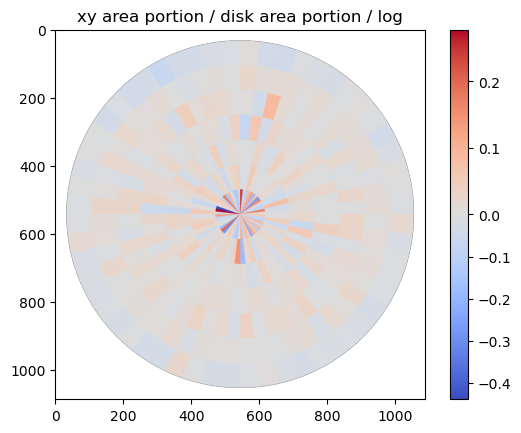

In [17]:
from matplotlib.colors import TwoSlopeNorm
plt.figure()
plt.imshow(uv_area[0], cmap='coolwarm')
plt.title("disk area portion")
plt.colorbar()

plt.savefig(os.path.join(reproducibility_save_path, "disk_area.svg"), dpi=600)
plt.show()
plt.close()

plt.figure()
plt.imshow(xy_img[0], cmap='coolwarm')
plt.title("xy area portion")
plt.colorbar()
#plt.savefig(os.path.join(save_folder, f"{ff}_xy_area.svg"), dpi=600)
plt.savefig(os.path.join(reproducibility_save_path, "xy_area.svg"), dpi=600)
plt.show()



ratio_values = ratio_disk[0]
print(np.nanmin(ratio_values),np.nanmax(ratio_values))
data = np.full_like(ratio_values, np.nan, dtype=float)
data[ratio_values>0] = np.log(ratio_values[ratio_values>0])  

# max_abs = np.max(np.abs(data))


plt.imshow(ratio_values,cmap='coolwarm')
plt.title("xy/disk")
plt.colorbar()
plt.savefig(os.path.join(reproducibility_save_path, "area_ratio.svg"), dpi=600)
plt.show()

vmin, vmax = np.nanmin(data), np.nanmax(data)
print(np.max(data))
plt.figure()
plt.imshow(data, cmap='coolwarm', norm=TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax))
plt.title("xy area portion / disk area portion / log")
plt.colorbar()
plt.savefig(os.path.join(reproducibility_save_path, "log_area_ratio.svg"), dpi=600)
plt.show()
#plt.savefig(os.path.join(save_folder, f"{ff}_ratio.svg"), dpi=600)
#plt.savefig(os.path.join(save_folder, "ratio", f"{ff}_ratio.svg"), dpi=600)
plt.close()

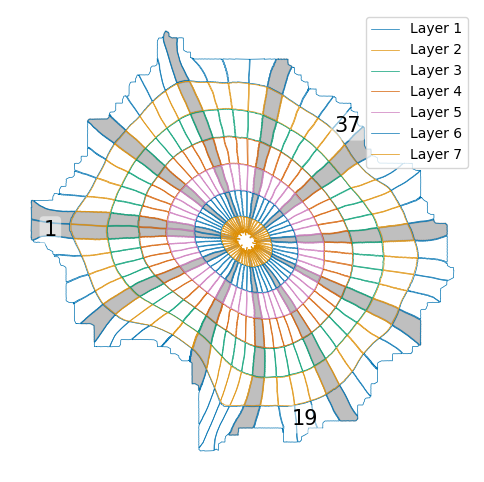

In [18]:
from window_overlay_display import window_display
output_folder = reproducibility_save_path
frame_n = 0
img_copy, all_xy = window_display(window_stack[0], THETA_NUM, R_NUM, output_folder, frame_n, file_name = f"{cell_name}_window", color_track = True,img = None, img_gray = None, color_layer = True)